# Sprint 1: SQLite, EDA i baseline model

Notebook realizuje wymagania sprintu 1 dla zbioru `Airline Passenger Satisfaction`.

Zakres:
- odczyt danych z `SQLite`
- statystyki opisowe i kontrola jakości danych
- minimum 5 wizualizacji
- podział `train/validation/test = 70/15/15`

Wstęp do sprintu 2:
- baseline model `RandomForestClassifier`
- zapis metryk do `reports/metrics/baseline_metrics.json`

## 1. Przygotowanie srodowiska



In [1]:
from pathlib import Path
import json
import sqlite3

import matplotlib.pyplot as plt
import pandas as pd
import seaborn as sns
from sklearn.compose import ColumnTransformer
from sklearn.ensemble import RandomForestClassifier
from sklearn.impute import SimpleImputer
from sklearn.metrics import accuracy_score, f1_score, precision_score, recall_score, roc_auc_score
from sklearn.model_selection import train_test_split
from sklearn.pipeline import Pipeline
from sklearn.preprocessing import OneHotEncoder

sns.set_theme(style="whitegrid")
pd.set_option("display.max_columns", 100)

project_root = Path.cwd().resolve()
if not (project_root / "data").exists():
    project_root = project_root.parent

# Sciezki do bazy SQLite i pliku z metrykami baseline modelu.
db_path = project_root / "data" / "01_raw" / "dataset.db"
metrics_path = project_root / "reports" / "metrics" / "baseline_metrics.json"
metrics_path.parent.mkdir(parents=True, exist_ok=True)

db_path

WindowsPath('D:/PRACA/asi/data/01_raw/dataset.db')

## 2. Wczytanie danych i szybka kontrola jakosci

Najpierw pobieramy dane z SQLite, a potem porzadkujemy typy kolumn. To przygotowuje zbior pod statystyki, wykresy i model.

In [2]:
# Odczyt danych bezposrednio z SQLite.
connection = sqlite3.connect(db_path)
df = pd.read_sql_query("SELECT * FROM airline_passenger_satisfaction", connection)
connection.close()

# Ujednolicanie nazw kolumn i brakujace wartosci.
df = df.rename(columns=lambda col: col.strip())
df = df.replace({"": pd.NA, "NA": pd.NA, "NaN": pd.NA})

numeric_columns = [
    "ID",
    "Age",
    "Flight Distance",
    "Departure Delay",
    "Arrival Delay",
    "Departure and Arrival Time Convenience",
    "Ease of Online Booking",
    "Check-in Service",
    "Online Boarding",
    "Gate Location",
    "On-board Service",
    "Seat Comfort",
    "Leg Room Service",
    "Cleanliness",
    "Food and Drink",
    "In-flight Service",
    "In-flight Wifi Service",
    "In-flight Entertainment",
    "Baggage Handling",
]

for column in numeric_columns:
    df[column] = pd.to_numeric(df[column], errors="coerce")

for column in df.columns:
    if column not in numeric_columns:
        df[column] = df[column].astype("string")

df.head()

,ID,Gender,Age,Customer Type,Type of Travel,Class,Flight Distance,Departure Delay,Arrival Delay,Departure and Arrival Time Convenience,Ease of Online Booking,Check-in Service,Online Boarding,Gate Location,On-board Service,Seat Comfort,Leg Room Service,Cleanliness,Food and Drink,In-flight Service,In-flight Wifi Service,In-flight Entertainment,Baggage Handling,Satisfaction
0,1,Male,48,First-time,Business,Business,821,2,5.0,3,3,4,3,3,3,5,2,5,5,5,3,5,5,Neutral or Dissatisfied
1,2,Female,35,Returning,Business,Business,821,26,39.0,2,2,3,5,2,5,4,5,5,3,5,2,5,5,Satisfied
2,3,Male,41,Returning,Business,Business,853,0,0.0,4,4,4,5,4,3,5,3,5,5,3,4,3,3,Satisfied
3,4,Male,50,Returning,Business,Business,1905,0,0.0,2,2,3,4,2,5,5,5,4,4,5,2,5,5,Satisfied
4,5,Female,49,Returning,Business,Business,3470,0,1.0,3,3,3,5,3,3,4,4,5,4,3,3,3,3,Satisfied


In [3]:
summary = {
    "rows": len(df),
    "columns": df.shape[1],
    "target_distribution": df["Satisfaction"].value_counts(dropna=False).to_dict(),
}

# Krotkie podsumowanie zbioru
summary

{'rows': 129880,
 'columns': 24,
 'target_distribution': {'Neutral or Dissatisfied': 73452, 'Satisfied': 56428}}

In [4]:
# Statystyki opisowe
df.describe(include="all").transpose()

,count,unique,top,freq,mean,std,min,25%,50%,75%,max
ID,129880.0,NaN,NaN,NaN,64940.5,37493.270818,1.0,32470.75,64940.5,97410.25,129880.0
Gender,129880,2,Female,65899,NaN,NaN,NaN,NaN,NaN,NaN,NaN
Age,129880.0,NaN,NaN,NaN,39.427957,15.11936,7.0,27.0,40.0,51.0,85.0
Customer Type,129880,2,Returning,106100,NaN,NaN,NaN,NaN,NaN,NaN,NaN
Type of Travel,129880,2,Business,89693,NaN,NaN,NaN,NaN,NaN,NaN,NaN
Class,129880,3,Business,62160,NaN,NaN,NaN,NaN,NaN,NaN,NaN
Flight Distance,129880.0,NaN,NaN,NaN,1190.316392,997.452477,31.0,414.0,844.0,1744.0,4983.0
Departure Delay,129880.0,NaN,NaN,NaN,14.713713,38.071126,0.0,0.0,0.0,12.0,1592.0
Arrival Delay,129487.0,NaN,NaN,NaN,15.091129,38.46565,0.0,0.0,0.0,13.0,1584.0
Departure and Arrival Time Convenience,129880.0,NaN,NaN,NaN,3.057599,1.526741,0.0,2.0,3.0,4.0,5.0


In [5]:
# Sprawdzenie czy są braki danych i duplikaty
missing_values = df.isna().sum().sort_values(ascending=False)
duplicate_rows = int(df.duplicated().sum())

pd.DataFrame(
    {
        "missing_values": missing_values,
        "missing_share": (missing_values / len(df)).round(4),
    }
).query("missing_values > 0"), duplicate_rows

(               missing_values  missing_share
 Arrival Delay             393          0.003,
 0)

## 3. EDA i wizualizacje


C:\Users\magma\AppData\Local\Temp\ipykernel_31932\531167057.py:4: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.countplot(data=df, x="Satisfaction", ax=axes[0], palette="Set2")


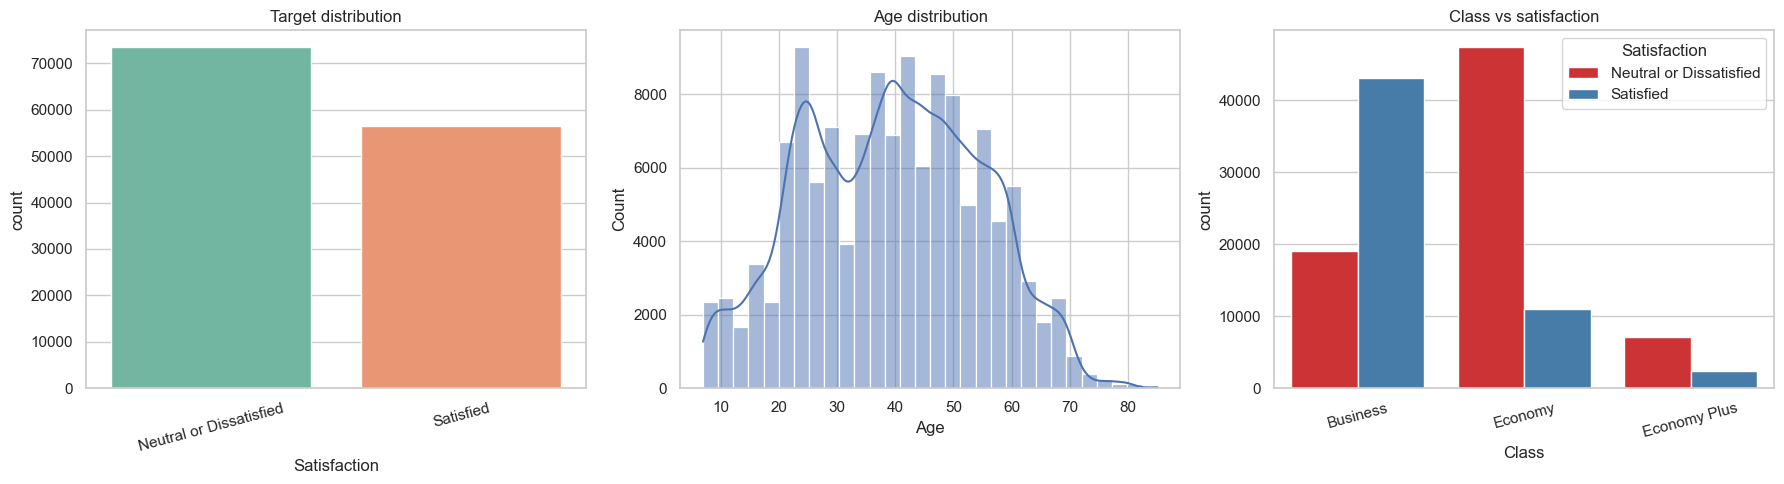

In [6]:
# Pierwszy zestaw wykresow: target, wiek i klasa lotu vs satysfakcja.
fig, axes = plt.subplots(1, 3, figsize=(18, 5))

sns.countplot(data=df, x="Satisfaction", ax=axes[0], palette="Set2")
axes[0].set_title("Target distribution")
axes[0].tick_params(axis="x", rotation=15)

sns.histplot(data=df, x="Age", bins=30, kde=True, ax=axes[1], color="#4C72B0")
axes[1].set_title("Age distribution")

sns.countplot(data=df, x="Class", hue="Satisfaction", ax=axes[2], palette="Set1")
axes[2].set_title("Class vs satisfaction")
axes[2].tick_params(axis="x", rotation=15)

plt.tight_layout()


- Klasa docelowa jest dość dobrze zbalansowana, rekordów `Neutral or Dissatisfied` jest troche wiecej.
- Wiek pasażerów jest rozłożony szeroko, bez jednej skrajnie dominujacej grupy.
- Na wykresie `Class vs satisfaction` widać, ze w klasie biznes satysfakcja pojawia się częściej niż w klasach tańszych

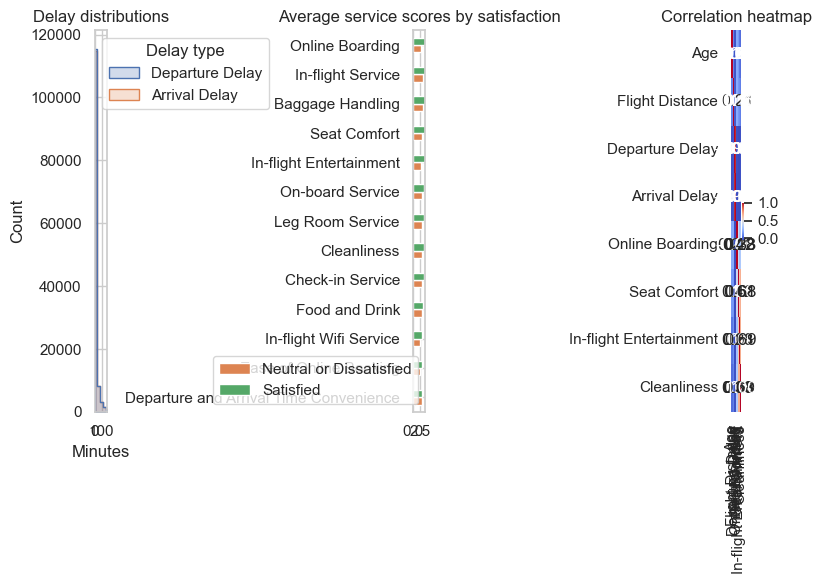

In [7]:
# Drugi zestaw: opóźnienia, średnie oceny usług i korelacje liczbowe.
fig, axes = plt.subplots(1, 3, figsize=(20, 5))

delay_frame = df[["Departure Delay", "Arrival Delay"]].melt(var_name="Delay type", value_name="Minutes")
sns.histplot(data=delay_frame, x="Minutes", hue="Delay type", bins=40, element="step", ax=axes[0])
axes[0].set_title("Delay distributions")
axes[0].set_xlim(0, delay_frame["Minutes"].quantile(0.99))

service_columns = [
    "Departure and Arrival Time Convenience",
    "Ease of Online Booking",
    "Check-in Service",
    "Online Boarding",
    "On-board Service",
    "Seat Comfort",
    "Leg Room Service",
    "Cleanliness",
    "Food and Drink",
    "In-flight Service",
    "In-flight Wifi Service",
    "In-flight Entertainment",
    "Baggage Handling",
]

(
    df.groupby("Satisfaction")[service_columns]
    .mean()
    .T.sort_values("Satisfied")
    .plot(kind="barh", figsize=(8, 6), ax=axes[1], color=["#DD8452", "#55A868"])
)
axes[1].set_title("Average service scores by satisfaction")
axes[1].legend(loc="lower right")

corr_columns = [
    "Age",
    "Flight Distance",
    "Departure Delay",
    "Arrival Delay",
    "Online Boarding",
    "Seat Comfort",
    "In-flight Entertainment",
    "Cleanliness",
]
sns.heatmap(df[corr_columns].corr(), annot=True, cmap="coolwarm", fmt=".2f", ax=axes[2])
axes[2].set_title("Correlation heatmap")

plt.tight_layout()



- większość lotów ma małe opóźnienie, ale pojawiają się też pojedyncze wysokie wartości.
- Średnie oceny usług sa wyraznie wyzsze dla grupy `Satisfied`
- Heatmapa pokazuje dodatnie zależności między wybranymi ocenami usług, ale nie są to korelacje idealne

## 4. Przygotowanie danych do modelu



In [8]:
model_df = df.drop_duplicates().copy()
model_df["target"] = (model_df["Satisfaction"].str.lower() == "satisfied").astype(int)

# ID nie trafia do modelu.
X = model_df.drop(columns=["Satisfaction", "target", "ID"])
y = model_df["target"]

# Rozdzielamy cechy liczbowe i kategoryczne pod preprocessing.
categorical_features = X.select_dtypes(include=["object", "string", "category"]).columns.tolist()
numeric_features = [column for column in X.columns if column not in categorical_features]

# train 70%, pozostałe 30% dzielimy po połowie na validation i test.
X_train, X_temp, y_train, y_temp = train_test_split(
    X,
    y,
    test_size=0.30,
    random_state=42,
    stratify=y,
)
X_val, X_test, y_val, y_test = train_test_split(
    X_temp,
    y_temp,
    test_size=0.50,
    random_state=42,
    stratify=y_temp,
)

# Kontrola rozmiarów splitu.
{
    "train": X_train.shape,
    "validation": X_val.shape,
    "test": X_test.shape,
}

{'train': (90916, 22), 'validation': (19482, 22), 'test': (19482, 22)}

In [9]:
# Preprocessing: mediana dla liczbowych, najczęstsza wartość i one-hot dla kategorycznych.
preprocessor = ColumnTransformer(
    transformers=[
        (
            "num",
            Pipeline([
                ("imputer", SimpleImputer(strategy="median")),
            ]),
            numeric_features,
        ),
        (
            "cat",
            Pipeline([
                ("imputer", SimpleImputer(strategy="most_frequent")),
                ("encoder", OneHotEncoder(handle_unknown="ignore")),
            ]),
            categorical_features,
        ),
    ]
)

# Baseline model dla sprintu 1: RandomForestClassifier.
baseline_model = Pipeline(
    steps=[
        ("preprocessor", preprocessor),
        (
            "classifier",
            RandomForestClassifier(
                n_estimators=200,
                random_state=42,
                n_jobs=1,
                class_weight="balanced_subsample",
            ),
        ),
    ]
)

# Trening modelu na zbiorze treningowym.
baseline_model.fit(X_train, y_train)

,"steps steps: list of tuplesList of (name of step, estimator) tuples that are to be chained insequential order. To be compatible with the scikit-learn API, all stepsmust define `fit`. All non-last steps must also define `transform`. See:ref:`Combining Estimators ` for more details.","[('preprocessor', ...), ('classifier', ...)]"
,"transform_input transform_input: list of str, default=NoneThe names of the :term:`metadata` parameters that should be transformed by thepipeline before passing it to the step consuming it.This enables transforming some input arguments to ``fit`` (other than ``X``)to be transformed by the steps of the pipeline up to the step which requiresthem. Requirement is defined via :ref:`metadata routing `.For instance, this can be used to pass a validation set through the pipeline.You can only set this if metadata routing is enabled, which youcan enable using ``sklearn.set_config(enable_metadata_routing=True)``... versionadded:: 1.6",None
,"memory memory: str or object with the joblib.Memory interface, default=NoneUsed to cache the fitted transformers of the pipeline. The last stepwill never be cached, even if it is a transformer. By default, nocaching is performed. If a string is given, it is the path to thecaching directory. Enabling caching triggers a clone of the transformersbefore fitting. Therefore, the transformer instance given to thepipeline cannot be inspected directly. Use the attribute ``named_steps``or ``steps`` to inspect estimators within the pipeline. Caching thetransformers is advantageous when fitting is time consuming. See:ref:`sphx_glr_auto_examples_neighbors_plot_caching_nearest_neighbors.py`for an example on how to enable caching.",None
,"verbose verbose: bool, default=FalseIf True, the time elapsed while fitting each step will be printed as itis completed.",False
,"transformers transformers: list of tuplesList of (name, transformer, columns) tuples specifying thetransformer objects to be applied to subsets of the data.name : str Like in Pipeline and FeatureUnion, this allows the transformer and its parameters to be set using ``set_params`` and searched in grid search.transformer : {'drop', 'passthrough'} or estimator Estimator must support :term:`fit` and :term:`transform`. Special-cased strings 'drop' and 'passthrough' are accepted as well, to indicate to drop the columns or to pass them through untransformed, respectively.columns : str, array-like of str, int, array-like of int, array-like of bool, slice or callable Indexes the data on its second axis. Integers are interpreted as positional columns, while strings can reference DataFrame columns by name. A scalar string or int should be used where ``transformer`` expects X to be a 1d array-like (vector), otherwise a 2d array will be passed to the transformer. A callable is passed the input data `X` and can return any of the above. To select multiple columns by name or dtype, you can use :obj:`make_column_selector`.","[('num', ...), ('cat', ...)]"
,"remainder remainder: {'drop', 'passthrough'} or estimator, default='drop'By default, only the specified columns in `transformers` aretransformed and combined in the output, and the non-specifiedcolumns are dropped. (default of ``'drop'``).By specifying ``remainder='passthrough'``, all remaining columns thatwere not specified in `transformers`, but present in the data passedto `fit` will be automatically passed through. This subset of columnsis concatenated with the output of the transformers. For dataframes,extra columns not seen during `fit` will be excluded from the outputof `transform`.By setting ``remainder`` to be an estimator, the remainingnon-specified columns will use the ``remainder`` estimator. Theestimator must support :term:`fit` and :term:`transform`.Note that using this feature requires that the DataFrame columnsinput at :term:`fit` and :term:`transform` have identical order.",'drop'
,"sparse_threshold sparse_threshold: float, default=0.3If the output of the different transforme

## 5. Ewaluacja i zapis metryk



In [10]:
# Funkcja pomocnicza najważniejsze metryki klasyfikacji.
def evaluate_split(name: str, features: pd.DataFrame, target: pd.Series) -> dict:
    predictions = baseline_model.predict(features)
    probabilities = baseline_model.predict_proba(features)[:, 1]
    return {
        "accuracy": round(float(accuracy_score(target, predictions)), 4),
        "precision": round(float(precision_score(target, predictions)), 4),
        "recall": round(float(recall_score(target, predictions)), 4),
        "f1": round(float(f1_score(target, predictions)), 4),
        "roc_auc": round(float(roc_auc_score(target, probabilities)), 4),
        "size": int(len(target)),
    }


metrics = {
    "validation": evaluate_split("validation", X_val, y_val),
    "test": evaluate_split("test", X_test, y_test),
    "dataset": {
        "rows": int(len(model_df)),
        "features": int(X.shape[1]),
        "train_size": int(len(X_train)),
        "validation_size": int(len(X_val)),
        "test_size": int(len(X_test)),
        "duplicates_removed": int(df.duplicated().sum()),
    },
}

# Zapis do JSON
metrics_path.write_text(json.dumps(metrics, indent=2), encoding="utf-8")
metrics

{'validation': {'accuracy': 0.9619,
  'precision': 0.9712,
  'recall': 0.9401,
  'f1': 0.9554,
  'roc_auc': 0.9942,
  'size': 19482},
 'test': {'accuracy': 0.9639,
  'precision': 0.9731,
  'recall': 0.9431,
  'f1': 0.9578,
  'roc_auc': 0.9942,
  'size': 19482},
 'dataset': {'rows': 129880,
  'features': 22,
  'train_size': 90916,
  'validation_size': 19482,
  'test_size': 19482,
  'duplicates_removed': 0}}

## Wynik

Notebook korzysta z lokalnej bazy `SQLite` w `data/01_raw/dataset.db` i zapisuje koncowe metryki baseline modelu do `reports/metrics/baseline_metrics.json`.
